<a href="https://colab.research.google.com/github/h78837659-cmyk/machine-learning/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/student-por.csv",sep=";")
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


In [ ]:
df.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      649 non-null    object
 1   sex         649 non-null    object
 2   age         649 non-null    int64 
 3   address     649 non-null    object
 4   famsize     649 non-null    object
 5   Pstatus     649 non-null    object
 6   Medu        649 non-null    int64 
 7   Fedu        649 non-null    int64 
 8   Mjob        649 non-null    object
 9   Fjob        649 non-null    object
 10  reason      649 non-null    object
 11  guardian    649 non-null    object
 12  traveltime  649 non-null    int64 
 13  studytime   649 non-null    int64 
 14  failures    649 non-null    int64 
 15  schoolsup   649 non-null    object
 16  famsup      649 non-null    object
 17  paid        649 non-null    object
 18  activities  649 non-null    object
 19  nursery     649 non-null    object
 20  higher    

In [ ]:
from scipy.stats import f_oneway

gp_g3 = df[df["school"] == 'GP']['G3']
ms_g3 = df[df["school"] == 'MS']['G3']

f_statistic, p_value = f_oneway(gp_g3, ms_g3)

print("F-statistic:", f_statistic)
print("p-value:", p_value)

if p_value > 0.05:
    print("we accept the null hypothesis non significant")
else:
    print("we reject the null hypothesis significant")

F-statistic: 56.890676863371326
p-value: 1.5661990923002604e-13
we reject the null hypothesis significant


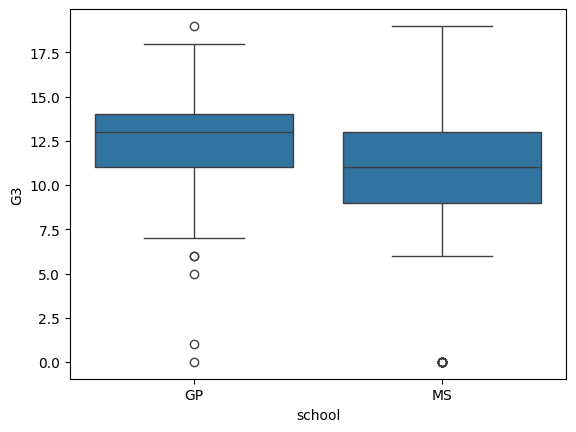

In [ ]:
sns.boxplot(x='school', y='G3', data=df)
plt.show()

In [ ]:
categorical_cols_1_to_5_categories = []
for col in df.select_dtypes(include='object').columns:
    if 1 <= df[col].nunique() <= 5:
        categorical_cols_1_to_5_categories.append(col)

print("Categorical columns with 1 to 5 unique categories:")
for col_name in categorical_cols_1_to_5_categories:
    print(col_name)

Categorical columns with 1 to 5 unique categories:
school
sex
address
famsize
Pstatus
Mjob
Fjob
reason
guardian
schoolsup
famsup
paid
activities
nursery
higher
internet
romantic


### ANOVA Test and Boxplot for each Categorical Column vs G3


--- Analyzing column: sex ---
F-statistic for sex: 10.962308407124876
p-value for sex: 0.0009815287061373291
For sex, we reject the null hypothesis (significant influence on G3).


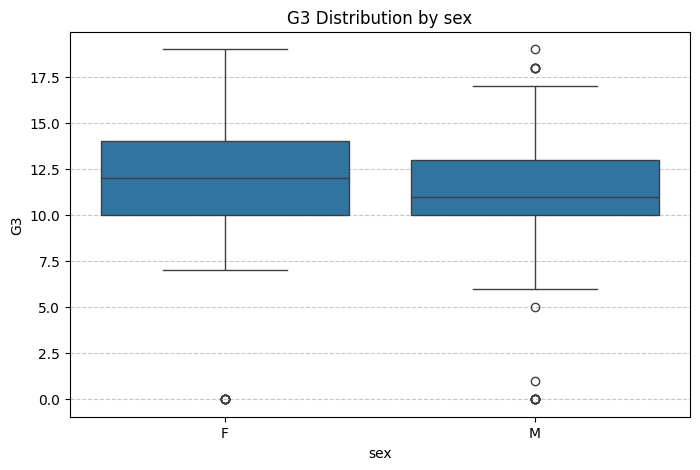


--- Analyzing column: address ---
F-statistic for address: 18.707910527412754
p-value for address: 1.7641534609222376e-05
For address, we reject the null hypothesis (significant influence on G3).


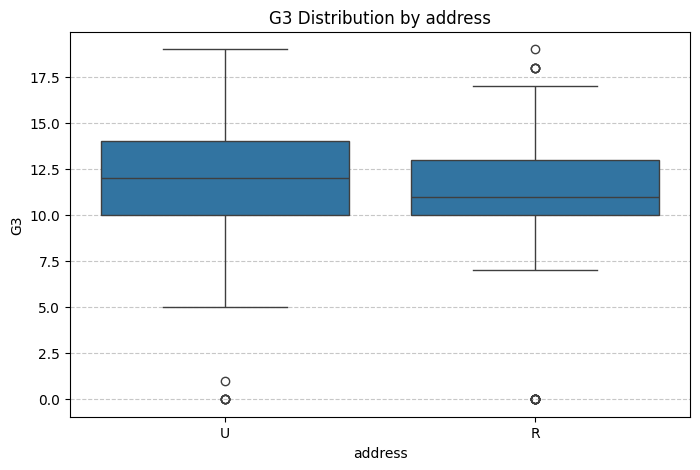


--- Analyzing column: famsize ---
F-statistic for famsize: 1.3137906447644496
p-value for famsize: 0.2521332216658235
For famsize, we accept the null hypothesis (non-significant influence on G3).


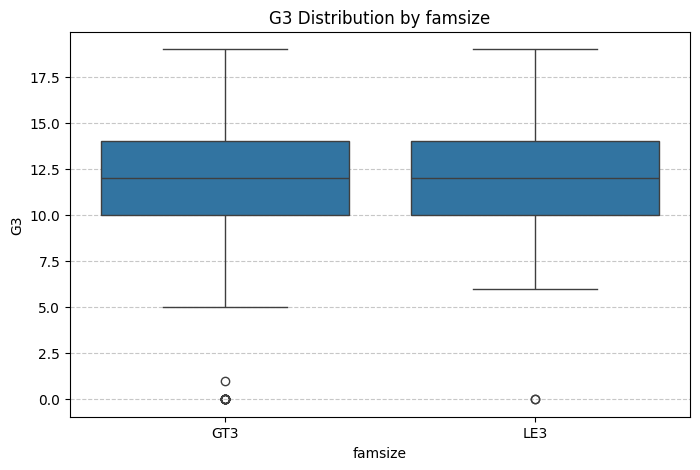


--- Analyzing column: Pstatus ---
F-statistic for Pstatus: 0.0003677569375753126
p-value for Pstatus: 0.984705825951084
For Pstatus, we accept the null hypothesis (non-significant influence on G3).


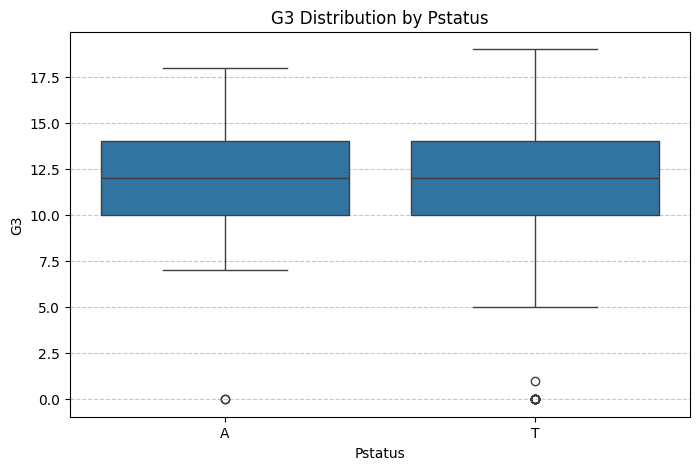


--- Analyzing column: Mjob ---
F-statistic for Mjob: 7.370224291121831
p-value for Mjob: 8.305149884947421e-06
For Mjob, we reject the null hypothesis (significant influence on G3).


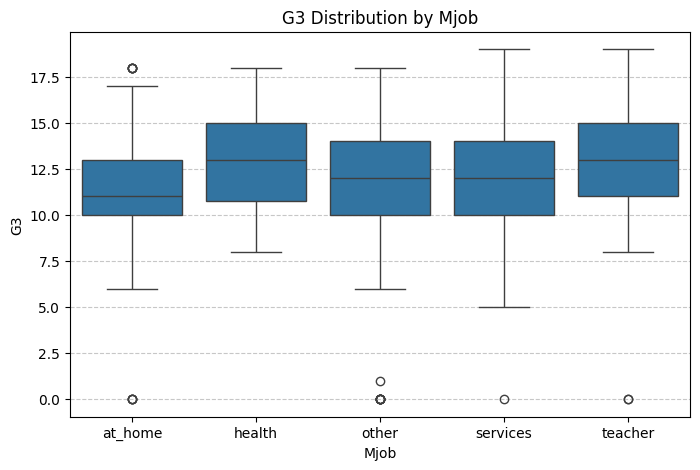


--- Analyzing column: Fjob ---
F-statistic for Fjob: 3.2726805958419676
p-value for Fjob: 0.01137628062360572
For Fjob, we reject the null hypothesis (significant influence on G3).


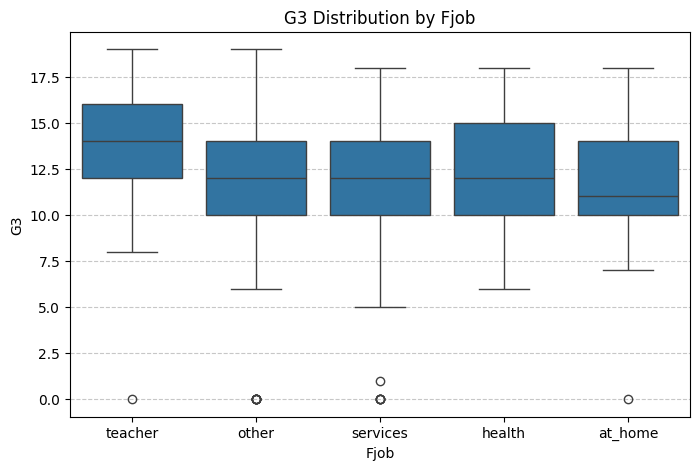


--- Analyzing column: reason ---
F-statistic for reason: 10.248465509132915
p-value for reason: 1.3416422874904325e-06
For reason, we reject the null hypothesis (significant influence on G3).


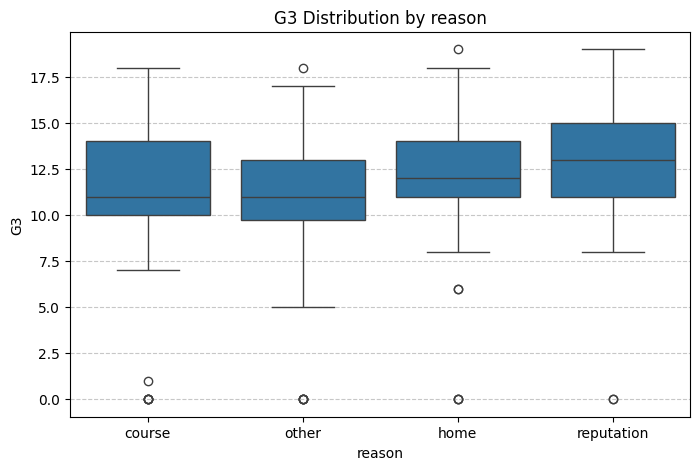


--- Analyzing column: guardian ---
F-statistic for guardian: 2.63816697870449
p-value for guardian: 0.07226239503367193
For guardian, we accept the null hypothesis (non-significant influence on G3).


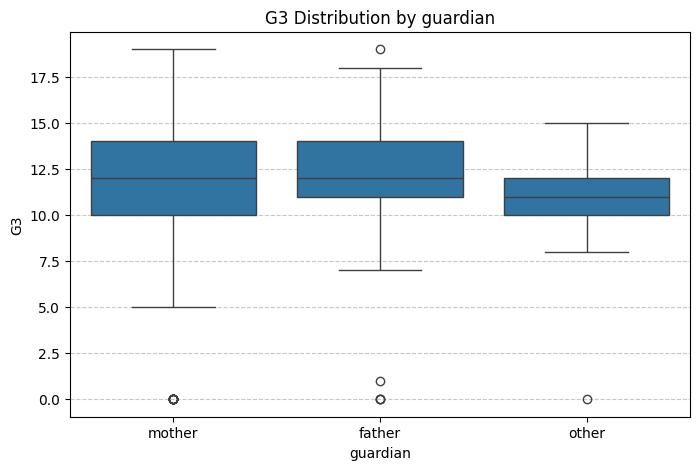


--- Analyzing column: schoolsup ---
F-statistic for schoolsup: 2.8656413604960576
p-value for schoolsup: 0.09097103846579589
For schoolsup, we accept the null hypothesis (non-significant influence on G3).


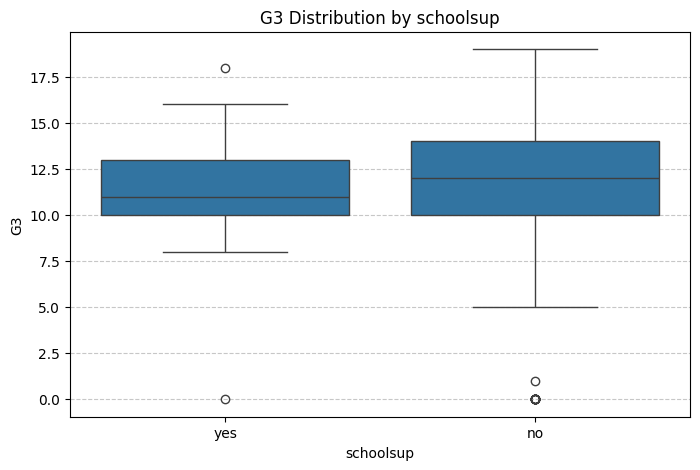


--- Analyzing column: famsup ---
F-statistic for famsup: 2.2759054076786045
p-value for famsup: 0.13188651204202523
For famsup, we accept the null hypothesis (non-significant influence on G3).


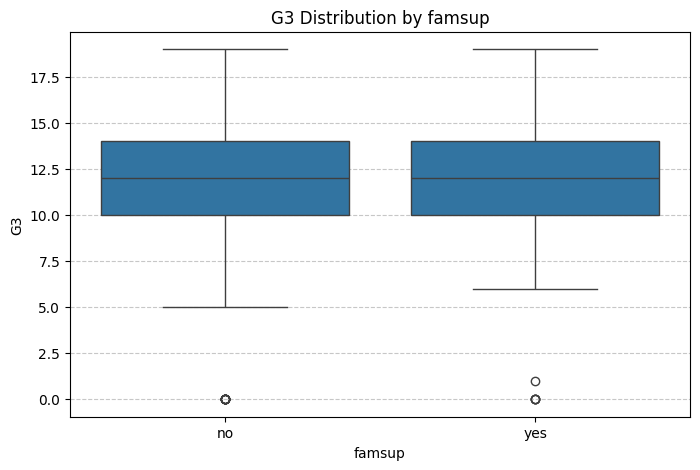


--- Analyzing column: paid ---
F-statistic for paid: 1.9558102256392806
p-value for paid: 0.1624412486356955
For paid, we accept the null hypothesis (non-significant influence on G3).


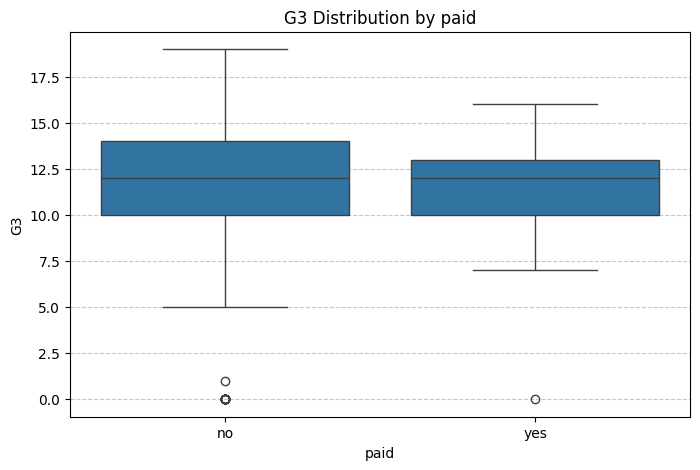


--- Analyzing column: activities ---
F-statistic for activities: 2.321335165021925
p-value for activities: 0.12809905950542522
For activities, we accept the null hypothesis (non-significant influence on G3).


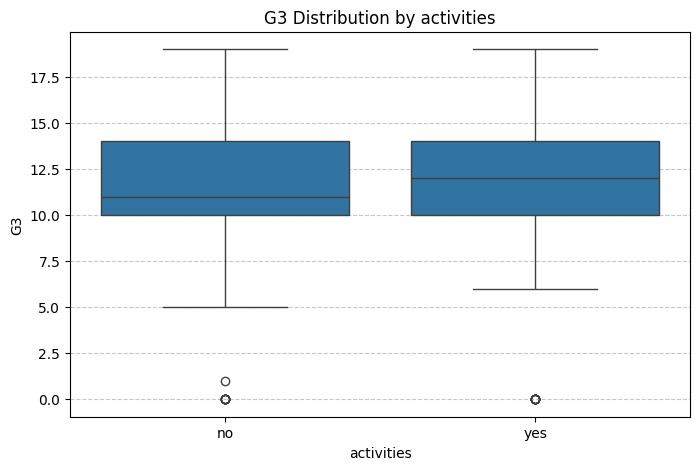


--- Analyzing column: nursery ---
F-statistic for nursery: 0.5353162586382413
p-value for nursery: 0.46464524309828237
For nursery, we accept the null hypothesis (non-significant influence on G3).


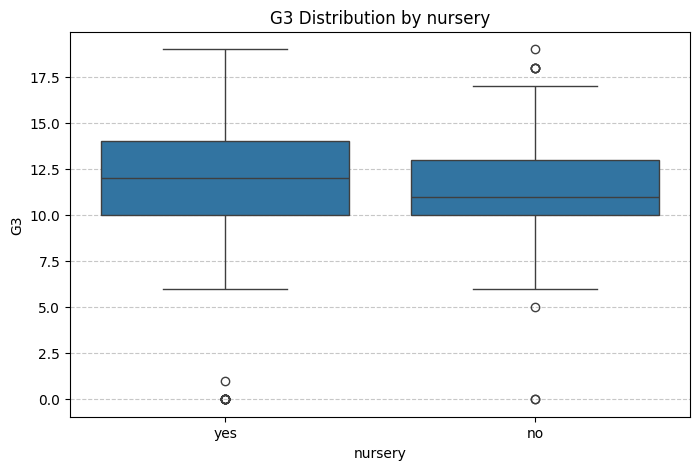


--- Analyzing column: higher ---
F-statistic for higher: 80.2424528790633
p-value for higher: 3.4996595928298785e-18
For higher, we reject the null hypothesis (significant influence on G3).


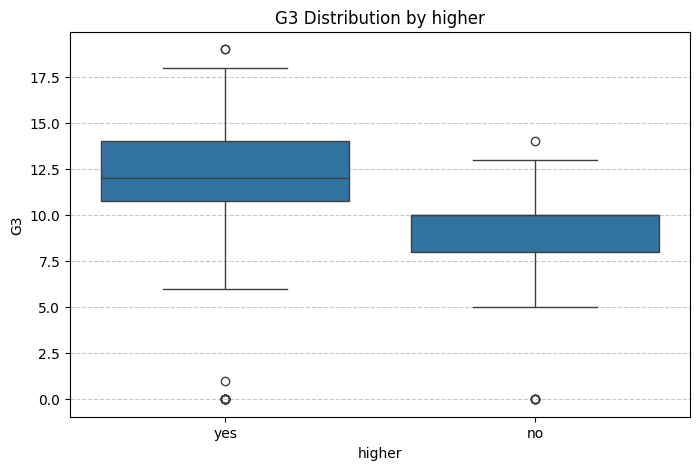


--- Analyzing column: internet ---
F-statistic for internet: 14.897632348195055
p-value for internet: 0.00012489173447451603
For internet, we reject the null hypothesis (significant influence on G3).


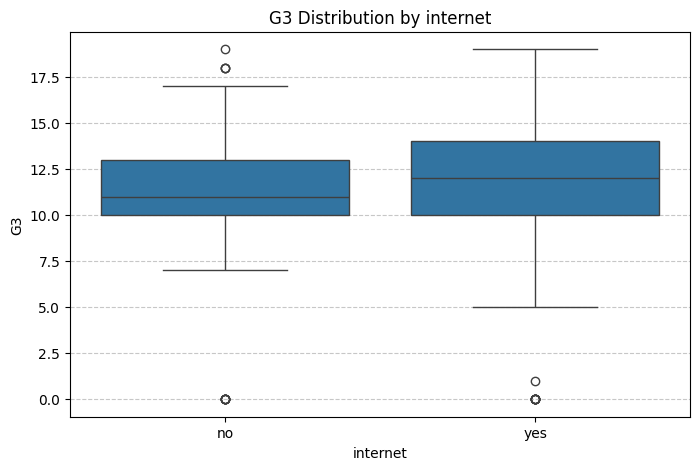


--- Analyzing column: romantic ---
F-statistic for romantic: 5.35272292081948
p-value for romantic: 0.02100247152464982
For romantic, we reject the null hypothesis (significant influence on G3).


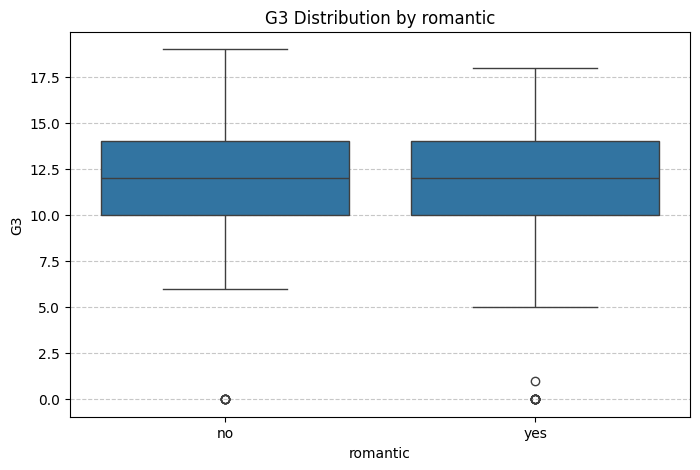


--- Summary of Significant Categorical Columns (p-value < 0.05) ---
['sex', 'address', 'Mjob', 'Fjob', 'reason', 'higher', 'internet', 'romantic']


In [ ]:
significant_categorical_cols = []

for col in categorical_cols_1_to_5_categories:
    # Skip 'school' as it was already analyzed in the notebook history
    if col == 'school':
        continue

    print(f"\n--- Analyzing column: {col} ---")

    # Get unique categories for the current column
    unique_categories = df[col].unique()

    # Prepare G3 scores for each category
    g3_scores_by_category = [df[df[col] == category]['G3'] for category in unique_categories]

    # Perform ANOVA test if there's more than one group
    if len(g3_scores_by_category) > 1:
        f_statistic, p_value = f_oneway(*g3_scores_by_category)

        print(f"F-statistic for {col}: {f_statistic}")
        print(f"p-value for {col}: {p_value}")

        if p_value < 0.05:
            print(f"For {col}, we reject the null hypothesis (significant influence on G3).")
            significant_categorical_cols.append(col)
        else:
            print(f"For {col}, we accept the null hypothesis (non-significant influence on G3).")

        # Generate boxplot
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.boxplot(x=col, y='G3', data=df, ax=ax)
        plt.title(f'G3 Distribution by {col}')
        plt.xlabel(col)
        plt.ylabel('G3')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
    else:
        print(f"Skipping ANOVA for {col} as it has only one category or all G3 scores are NaN for a category.")

print("\n--- Summary of Significant Categorical Columns (p-value < 0.05) ---")
print(significant_categorical_cols)

### Re-evaluating Significance of Categorical Columns for G3

--- Analyzing column: school ---
F-statistic for school: 56.890676863371326
p-value for school: 1.5661990923002604e-13
For school, we reject the null hypothesis (significant influence on G3).


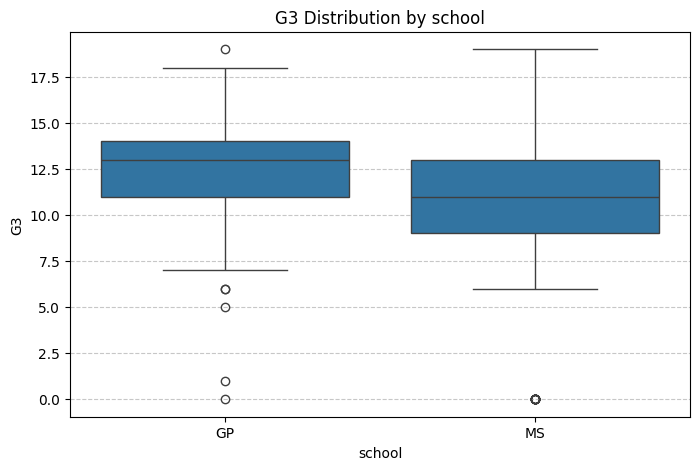


--- Analyzing column: sex ---
F-statistic for sex: 10.962308407124876
p-value for sex: 0.0009815287061373291
For sex, we reject the null hypothesis (significant influence on G3).


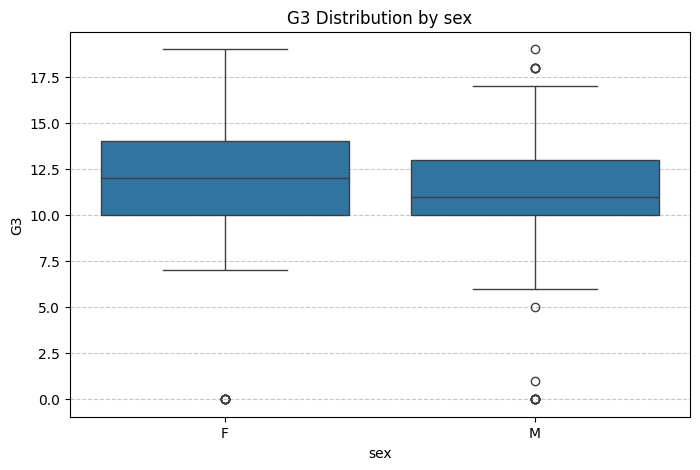


--- Analyzing column: address ---
F-statistic for address: 18.707910527412754
p-value for address: 1.7641534609222376e-05
For address, we reject the null hypothesis (significant influence on G3).


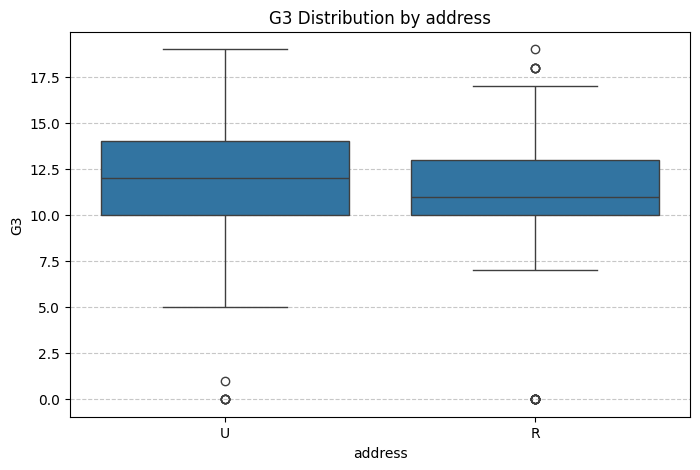


--- Analyzing column: famsize ---
F-statistic for famsize: 1.3137906447644496
p-value for famsize: 0.2521332216658235
For famsize, we accept the null hypothesis (non-significant influence on G3).


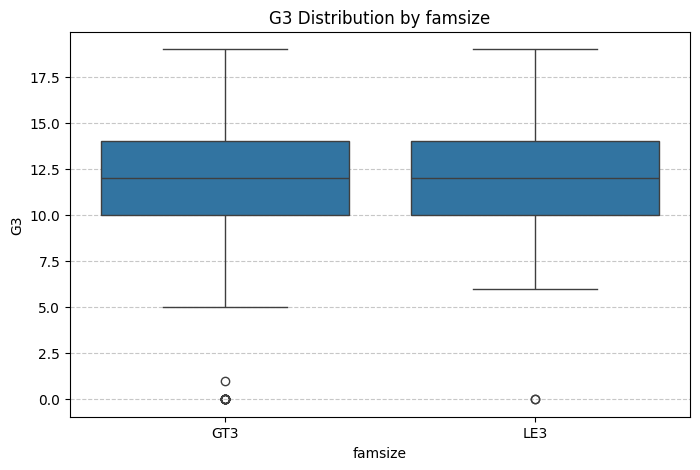


--- Analyzing column: Pstatus ---
F-statistic for Pstatus: 0.0003677569375753126
p-value for Pstatus: 0.984705825951084
For Pstatus, we accept the null hypothesis (non-significant influence on G3).


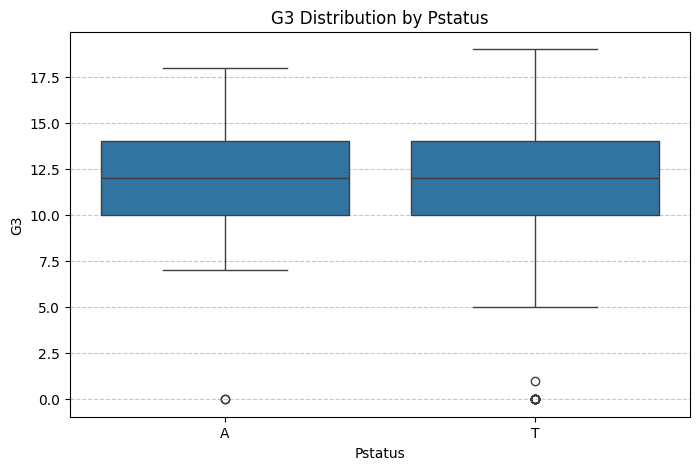


--- Analyzing column: Mjob ---
F-statistic for Mjob: 7.370224291121831
p-value for Mjob: 8.305149884947421e-06
For Mjob, we reject the null hypothesis (significant influence on G3).


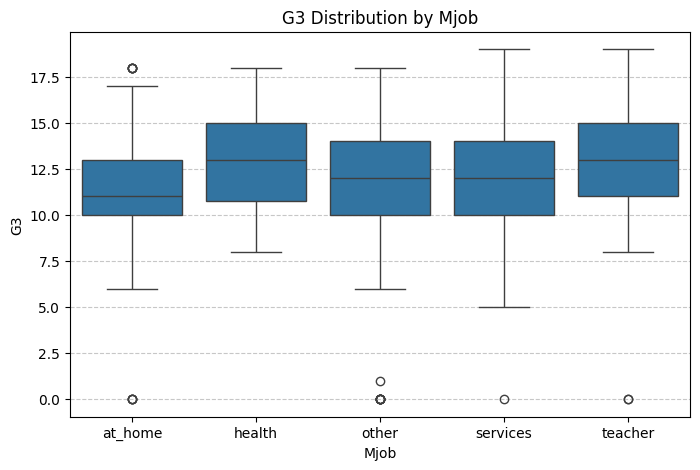


--- Analyzing column: Fjob ---
F-statistic for Fjob: 3.2726805958419676
p-value for Fjob: 0.01137628062360572
For Fjob, we reject the null hypothesis (significant influence on G3).


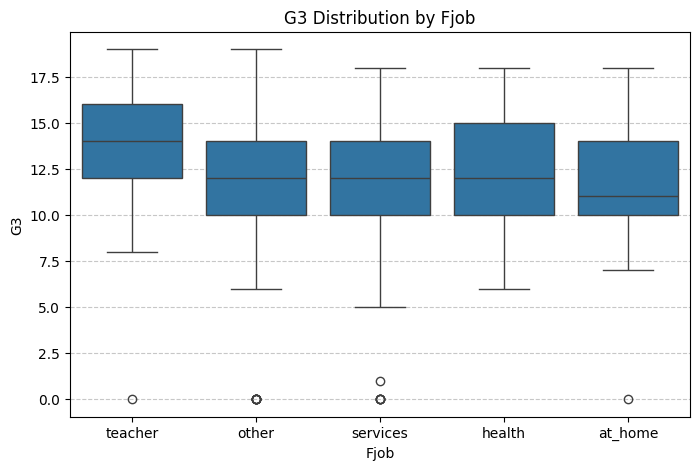


--- Analyzing column: reason ---
F-statistic for reason: 10.248465509132915
p-value for reason: 1.3416422874904325e-06
For reason, we reject the null hypothesis (significant influence on G3).


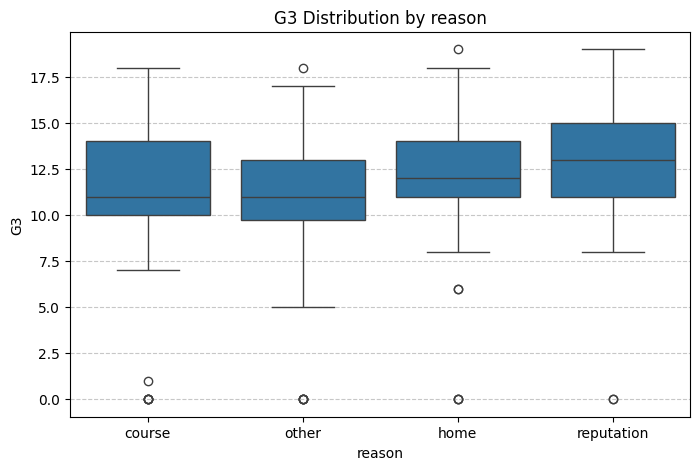


--- Analyzing column: guardian ---
F-statistic for guardian: 2.63816697870449
p-value for guardian: 0.07226239503367193
For guardian, we accept the null hypothesis (non-significant influence on G3).


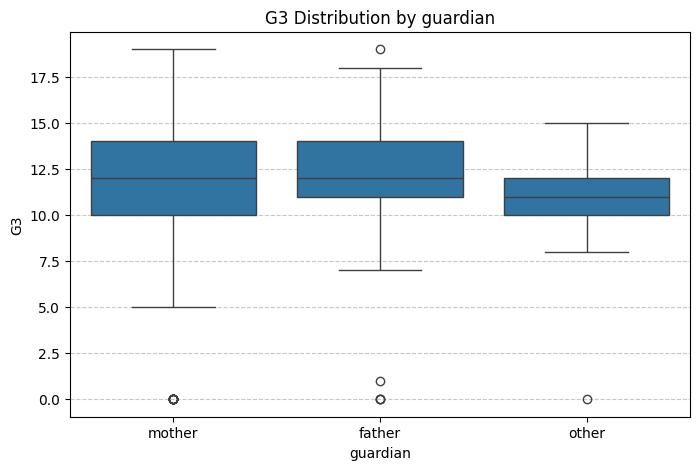


--- Analyzing column: schoolsup ---
F-statistic for schoolsup: 2.8656413604960576
p-value for schoolsup: 0.09097103846579589
For schoolsup, we accept the null hypothesis (non-significant influence on G3).


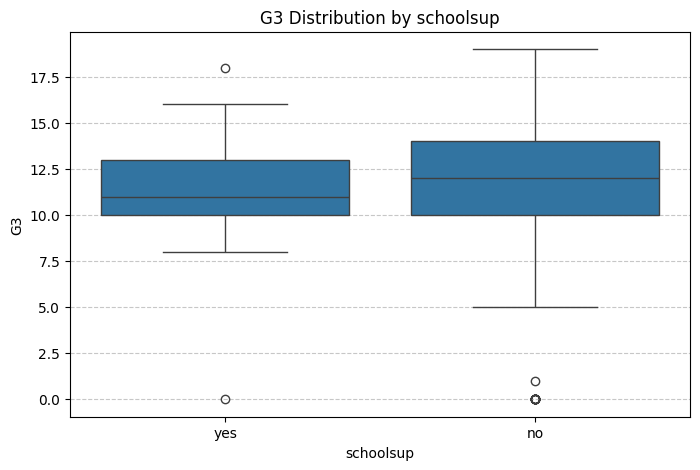


--- Analyzing column: famsup ---
F-statistic for famsup: 2.2759054076786045
p-value for famsup: 0.13188651204202523
For famsup, we accept the null hypothesis (non-significant influence on G3).


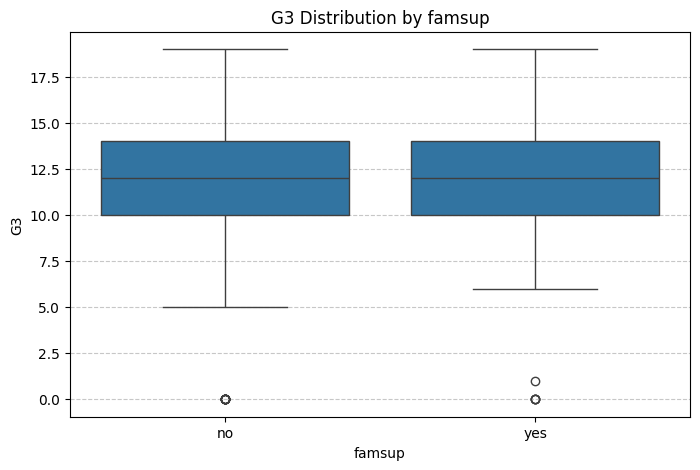


--- Analyzing column: paid ---
F-statistic for paid: 1.9558102256392806
p-value for paid: 0.1624412486356955
For paid, we accept the null hypothesis (non-significant influence on G3).


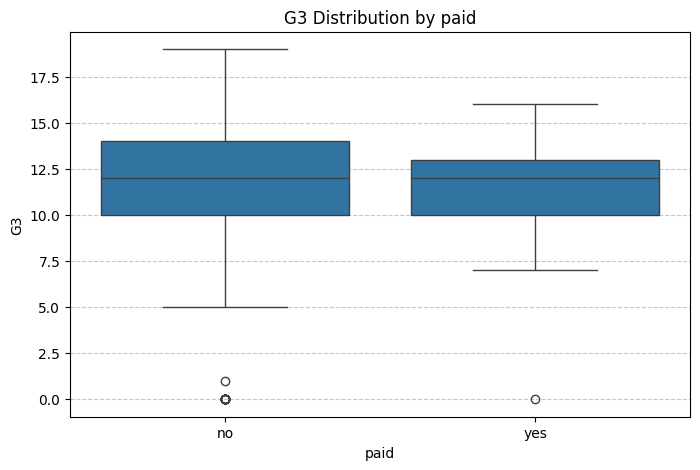


--- Analyzing column: activities ---
F-statistic for activities: 2.321335165021925
p-value for activities: 0.12809905950542522
For activities, we accept the null hypothesis (non-significant influence on G3).


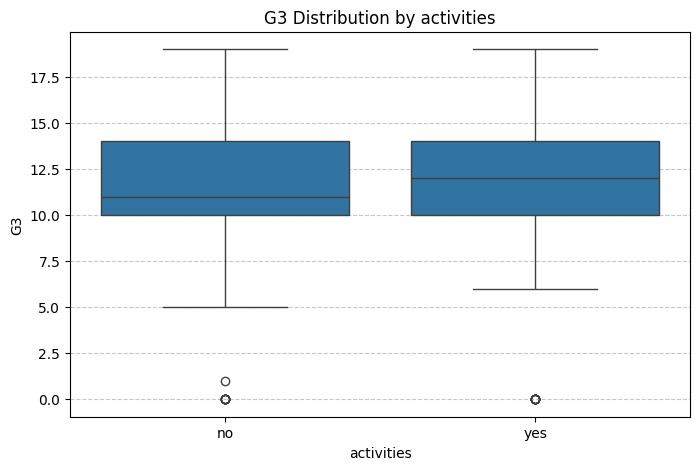


--- Analyzing column: nursery ---
F-statistic for nursery: 0.5353162586382413
p-value for nursery: 0.46464524309828237
For nursery, we accept the null hypothesis (non-significant influence on G3).


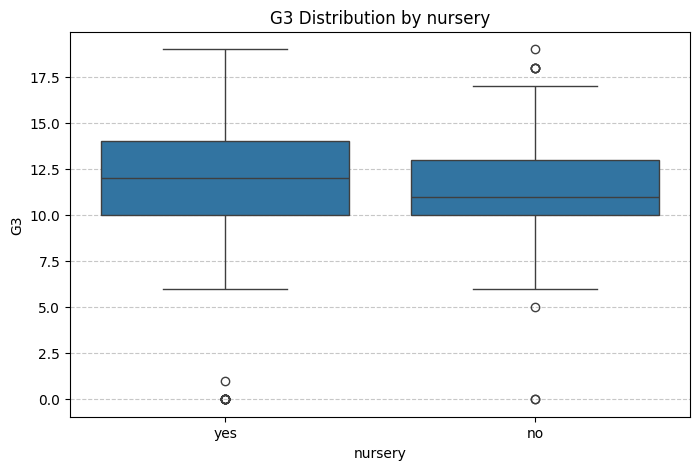


--- Analyzing column: higher ---
F-statistic for higher: 80.2424528790633
p-value for higher: 3.4996595928298785e-18
For higher, we reject the null hypothesis (significant influence on G3).


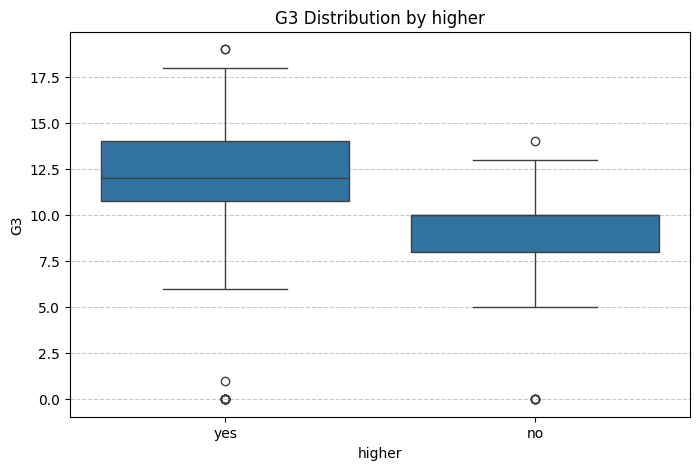


--- Analyzing column: internet ---
F-statistic for internet: 14.897632348195055
p-value for internet: 0.00012489173447451603
For internet, we reject the null hypothesis (significant influence on G3).


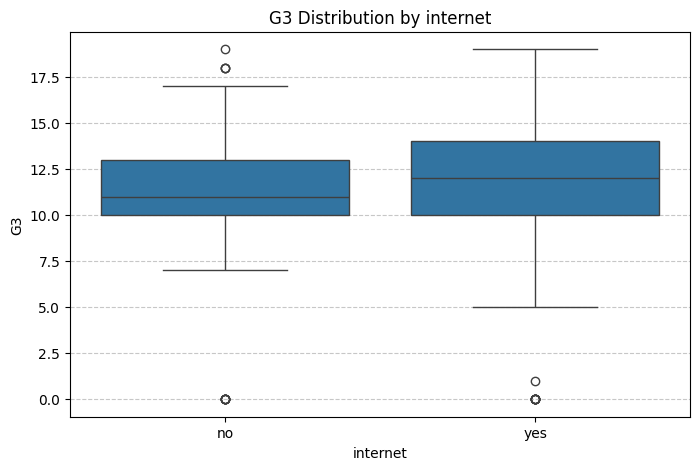


--- Analyzing column: romantic ---
F-statistic for romantic: 5.35272292081948
p-value for romantic: 0.02100247152464982
For romantic, we reject the null hypothesis (significant influence on G3).


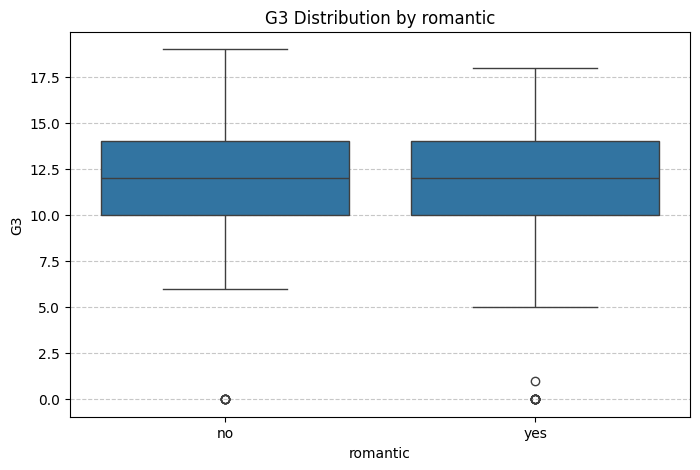


--- Final Summary of Significant Categorical Columns (p-value < 0.05) ---
['school', 'sex', 'address', 'Mjob', 'Fjob', 'reason', 'higher', 'internet', 'romantic']


In [ ]:
from scipy.stats import f_oneway
import matplotlib.pyplot as plt
import seaborn as sns

significant_categorical_cols_rechecked = []

# Ensure 'school' is checked first, as it was previously found significant
print("--- Analyzing column: school ---")
gp_g3 = df[df["school"] == 'GP']['G3']
ms_g3 = df[df["school"] == 'MS']['G3']

f_statistic_school, p_value_school = f_oneway(gp_g3, ms_g3)
print(f"F-statistic for school: {f_statistic_school}")
print(f"p-value for school: {p_value_school}")

if p_value_school < 0.05:
    print("For school, we reject the null hypothesis (significant influence on G3).")
    significant_categorical_cols_rechecked.append('school')
else:
    print("For school, we accept the null hypothesis (non-significant influence on G3).")

# Generate boxplot for school
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='school', y='G3', data=df, ax=ax)
plt.title('G3 Distribution by school')
plt.xlabel('school')
plt.ylabel('G3')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


# Now iterate through the rest of the previously identified categorical columns
for col in categorical_cols_1_to_5_categories:
    if col == 'school': # Already processed 'school'
        continue

    print(f"\n--- Analyzing column: {col} ---")

    unique_categories = df[col].unique()
    g3_scores_by_category = [df[df[col] == category]['G3'] for category in unique_categories]

    if len(g3_scores_by_category) > 1:
        # Filter out empty arrays that can cause issues with f_oneway
        g3_scores_by_category_filtered = [arr for arr in g3_scores_by_category if not arr.empty]

        if len(g3_scores_by_category_filtered) > 1:
            f_statistic, p_value = f_oneway(*g3_scores_by_category_filtered)

            print(f"F-statistic for {col}: {f_statistic}")
            print(f"p-value for {col}: {p_value}")

            if p_value < 0.05:
                print(f"For {col}, we reject the null hypothesis (significant influence on G3).")
                significant_categorical_cols_rechecked.append(col)
            else:
                print(f"For {col}, we accept the null hypothesis (non-significant influence on G3).")

            # Generate boxplot
            fig, ax = plt.subplots(figsize=(8, 5))
            sns.boxplot(x=col, y='G3', data=df, ax=ax)
            plt.title(f'G3 Distribution by {col}')
            plt.xlabel(col)
            plt.ylabel('G3')
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.show()
        else:
            print(f"Skipping ANOVA for {col} as there are not enough valid categories with G3 scores.")
    else:
        print(f"Skipping ANOVA for {col} as it has only one category.")

print("\n--- Final Summary of Significant Categorical Columns (p-value < 0.05) ---")
print(significant_categorical_cols_rechecked)

### Re-identifying All Potential Categorical/Ordinal Columns and Re-evaluating Significance for G3

All potential categorical/ordinal columns with 1 to 5 unique categories:
['school', 'sex', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']

--- Analyzing column: school ---
F-statistic for school: 56.890676863371326
p-value for school: 1.5661990923002604e-13
For school, we reject the null hypothesis (significant influence on G3).


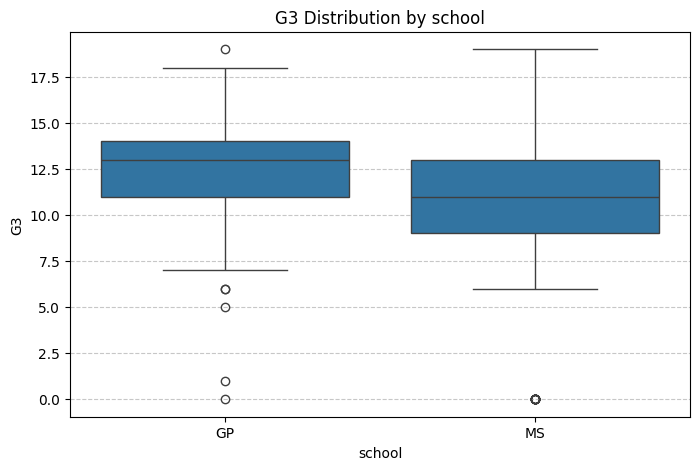


--- Analyzing column: sex ---
F-statistic for sex: 10.962308407124876
p-value for sex: 0.0009815287061373291
For sex, we reject the null hypothesis (significant influence on G3).


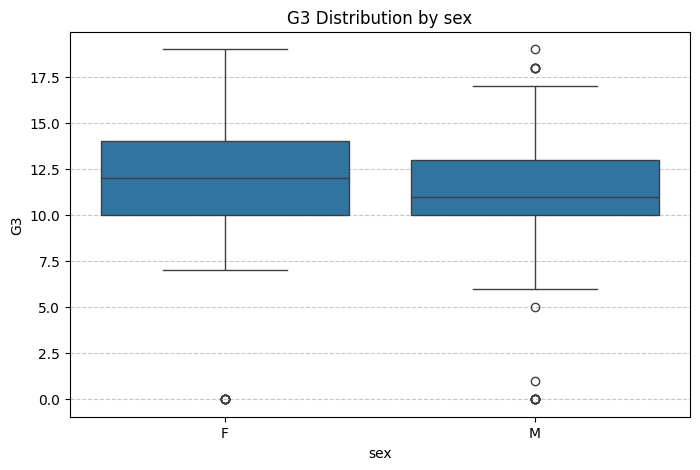


--- Analyzing column: address ---
F-statistic for address: 18.707910527412754
p-value for address: 1.7641534609222376e-05
For address, we reject the null hypothesis (significant influence on G3).


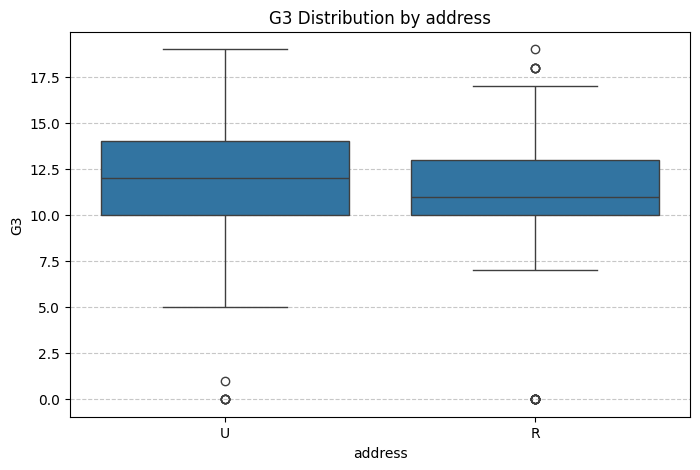


--- Analyzing column: famsize ---
F-statistic for famsize: 1.3137906447644496
p-value for famsize: 0.2521332216658235
For famsize, we accept the null hypothesis (non-significant influence on G3).


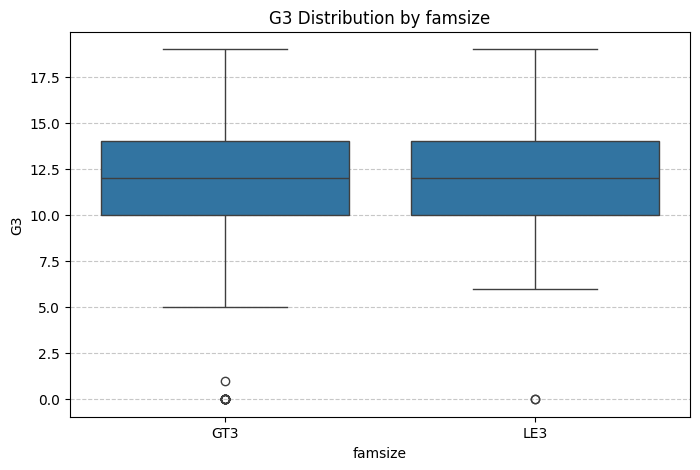


--- Analyzing column: Pstatus ---
F-statistic for Pstatus: 0.0003677569375753126
p-value for Pstatus: 0.984705825951084
For Pstatus, we accept the null hypothesis (non-significant influence on G3).


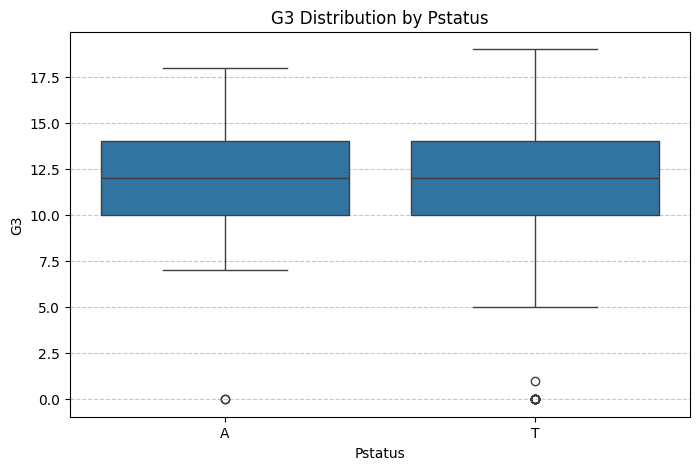


--- Analyzing column: Medu ---
F-statistic for Medu: 10.764276866816425
p-value for Medu: 1.8856851949016492e-08
For Medu, we reject the null hypothesis (significant influence on G3).


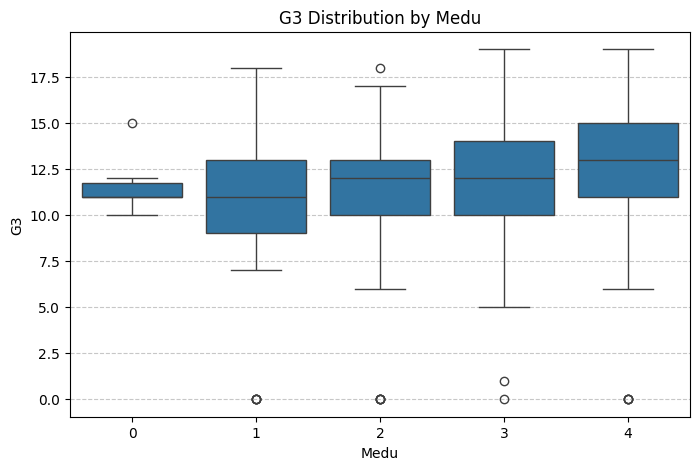


--- Analyzing column: Fedu ---
F-statistic for Fedu: 8.223361707146887
p-value for Fedu: 1.7991136867942303e-06
For Fedu, we reject the null hypothesis (significant influence on G3).


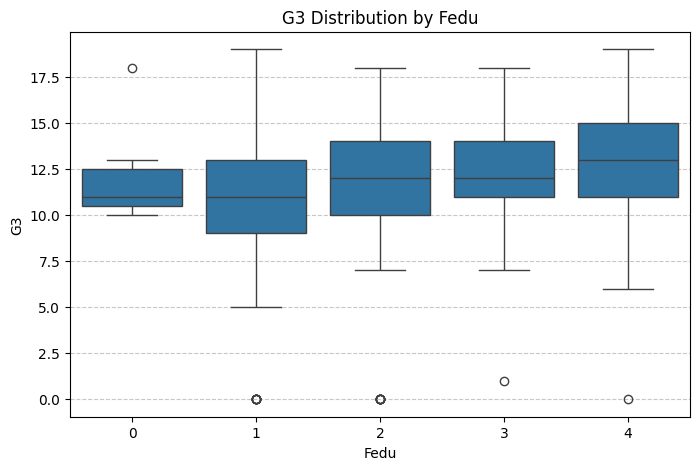


--- Analyzing column: Mjob ---
F-statistic for Mjob: 7.370224291121831
p-value for Mjob: 8.305149884947421e-06
For Mjob, we reject the null hypothesis (significant influence on G3).


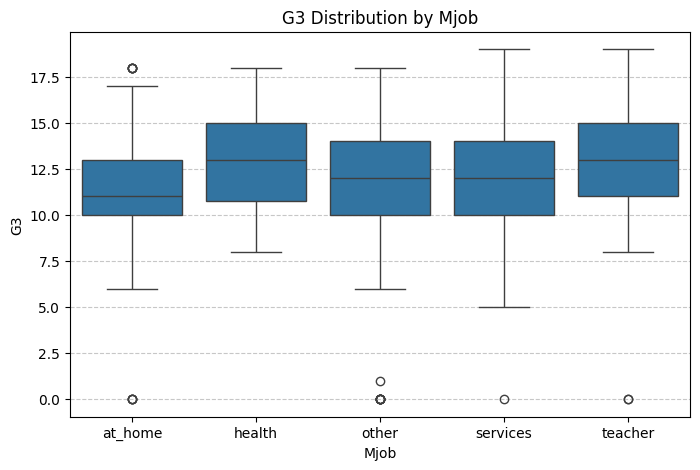


--- Analyzing column: Fjob ---
F-statistic for Fjob: 3.2726805958419676
p-value for Fjob: 0.01137628062360572
For Fjob, we reject the null hypothesis (significant influence on G3).


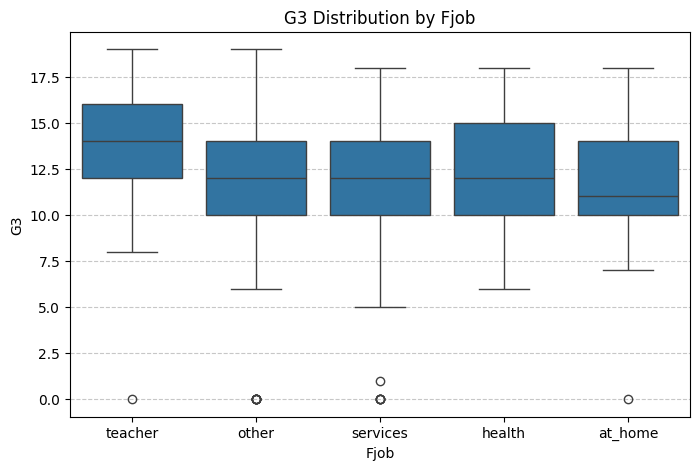


--- Analyzing column: reason ---
F-statistic for reason: 10.248465509132915
p-value for reason: 1.3416422874904325e-06
For reason, we reject the null hypothesis (significant influence on G3).


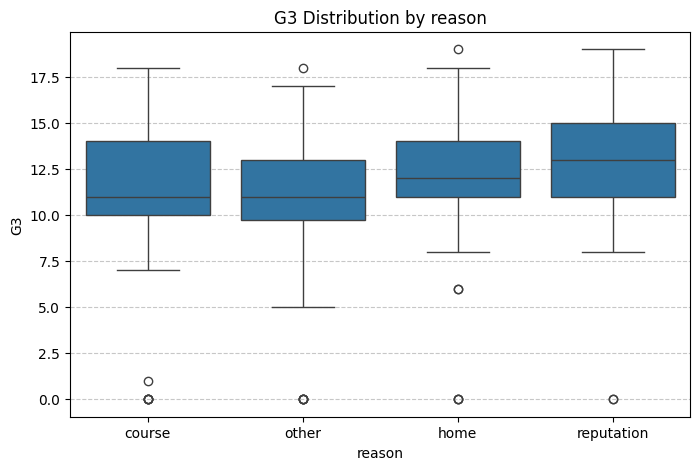


--- Analyzing column: guardian ---
F-statistic for guardian: 2.63816697870449
p-value for guardian: 0.07226239503367193
For guardian, we accept the null hypothesis (non-significant influence on G3).


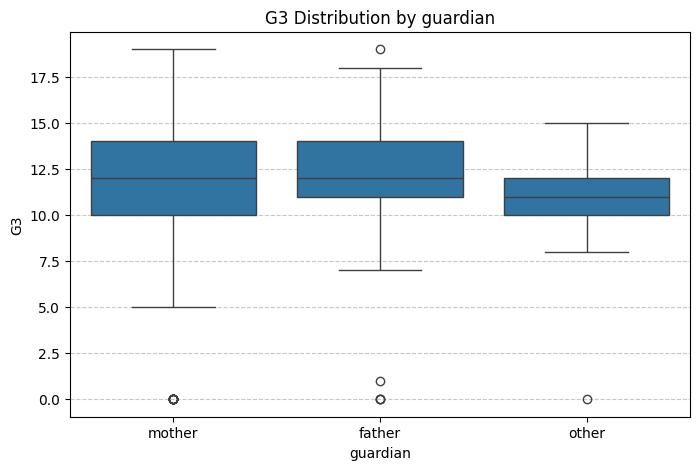


--- Analyzing column: traveltime ---
F-statistic for traveltime: 3.6588402487405807
p-value for traveltime: 0.012321097062069852
For traveltime, we reject the null hypothesis (significant influence on G3).


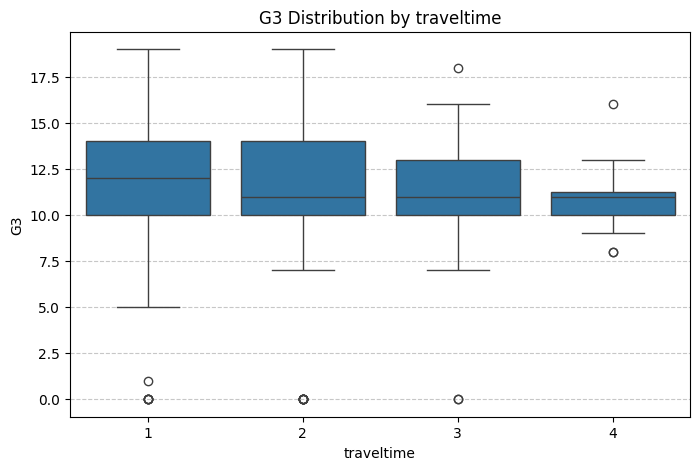


--- Analyzing column: studytime ---
F-statistic for studytime: 15.876267993177123
p-value for studytime: 5.705728458962843e-10
For studytime, we reject the null hypothesis (significant influence on G3).


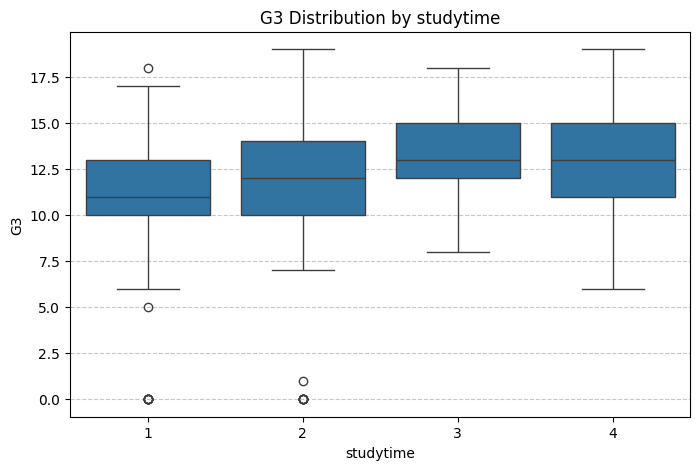


--- Analyzing column: failures ---
F-statistic for failures: 51.38582794045558
p-value for failures: 8.644516356430469e-30
For failures, we reject the null hypothesis (significant influence on G3).


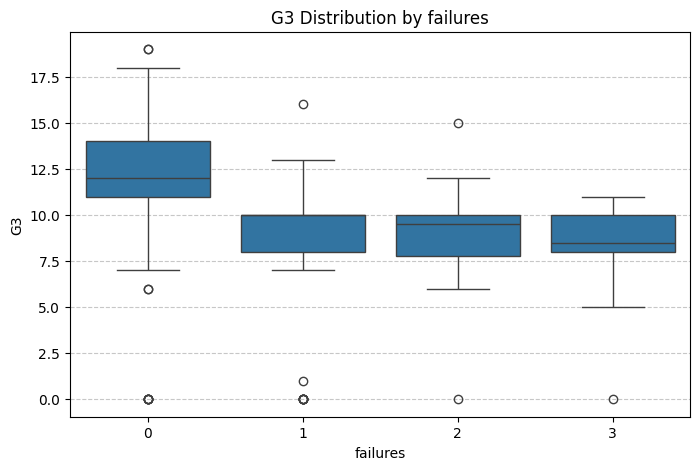


--- Analyzing column: schoolsup ---
F-statistic for schoolsup: 2.8656413604960576
p-value for schoolsup: 0.09097103846579589
For schoolsup, we accept the null hypothesis (non-significant influence on G3).


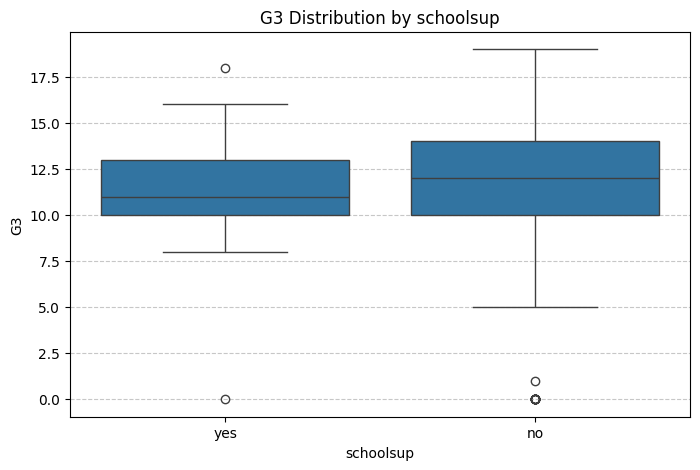


--- Analyzing column: famsup ---
F-statistic for famsup: 2.2759054076786045
p-value for famsup: 0.13188651204202523
For famsup, we accept the null hypothesis (non-significant influence on G3).


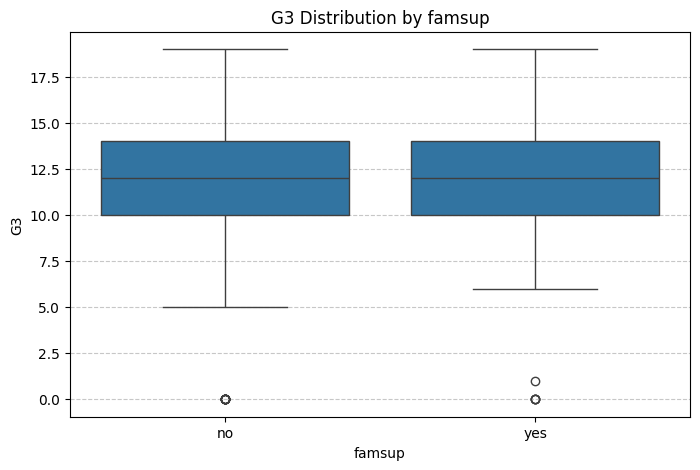


--- Analyzing column: paid ---
F-statistic for paid: 1.9558102256392806
p-value for paid: 0.1624412486356955
For paid, we accept the null hypothesis (non-significant influence on G3).


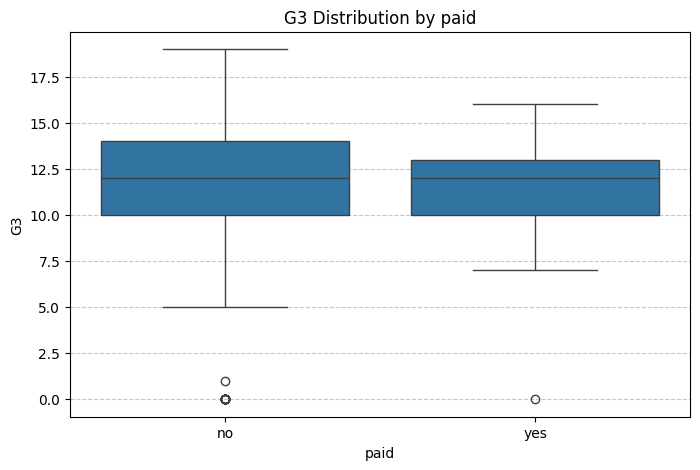


--- Analyzing column: activities ---
F-statistic for activities: 2.321335165021925
p-value for activities: 0.12809905950542522
For activities, we accept the null hypothesis (non-significant influence on G3).


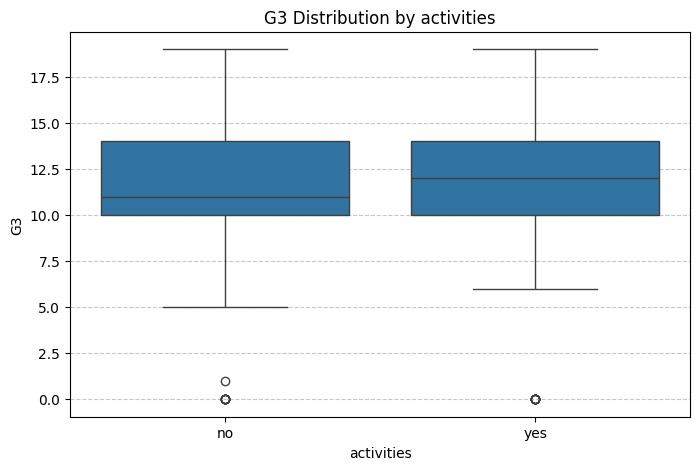


--- Analyzing column: nursery ---
F-statistic for nursery: 0.5353162586382413
p-value for nursery: 0.46464524309828237
For nursery, we accept the null hypothesis (non-significant influence on G3).


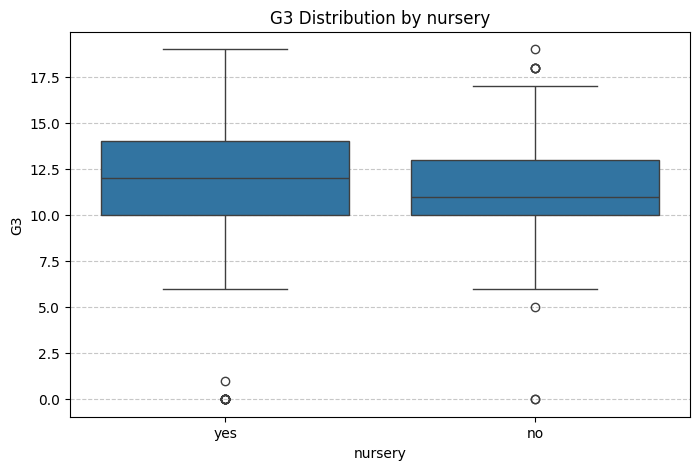


--- Analyzing column: higher ---
F-statistic for higher: 80.2424528790633
p-value for higher: 3.4996595928298785e-18
For higher, we reject the null hypothesis (significant influence on G3).


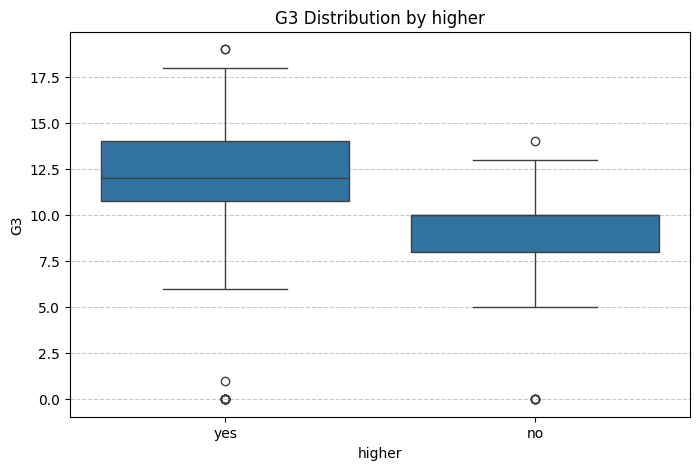


--- Analyzing column: internet ---
F-statistic for internet: 14.897632348195055
p-value for internet: 0.00012489173447451603
For internet, we reject the null hypothesis (significant influence on G3).


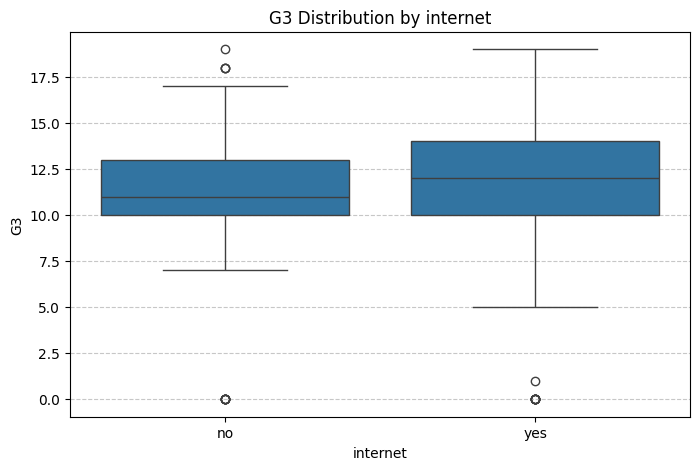


--- Analyzing column: romantic ---
F-statistic for romantic: 5.35272292081948
p-value for romantic: 0.02100247152464982
For romantic, we reject the null hypothesis (significant influence on G3).


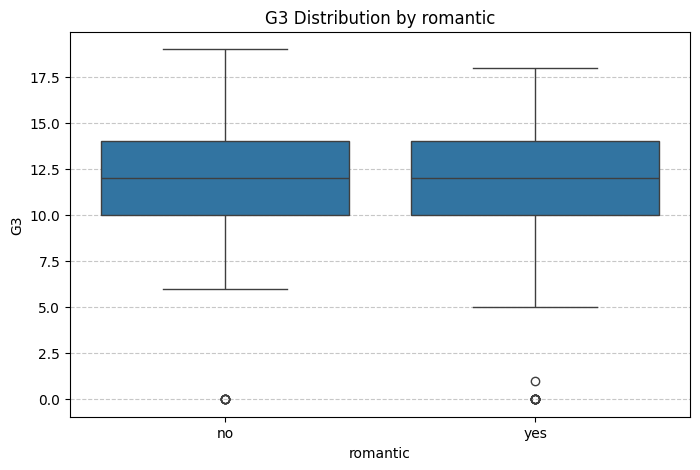


--- Analyzing column: famrel ---
F-statistic for famrel: 3.6779077023875293
p-value for famrel: 0.005684830602219902
For famrel, we reject the null hypothesis (significant influence on G3).


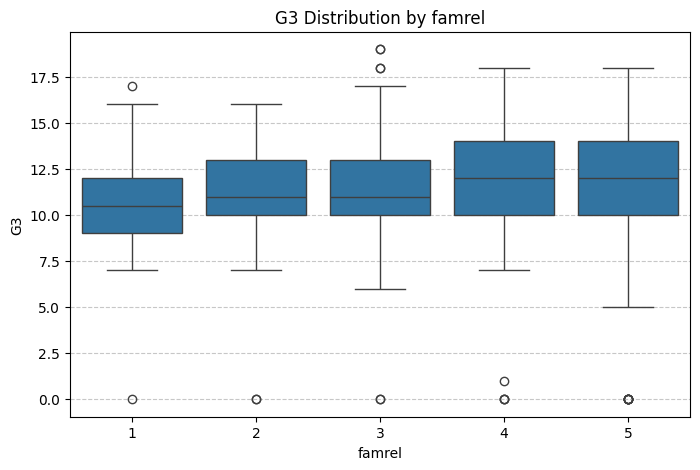


--- Analyzing column: freetime ---
F-statistic for freetime: 4.488592643212423
p-value for freetime: 0.001389612248145489
For freetime, we reject the null hypothesis (significant influence on G3).


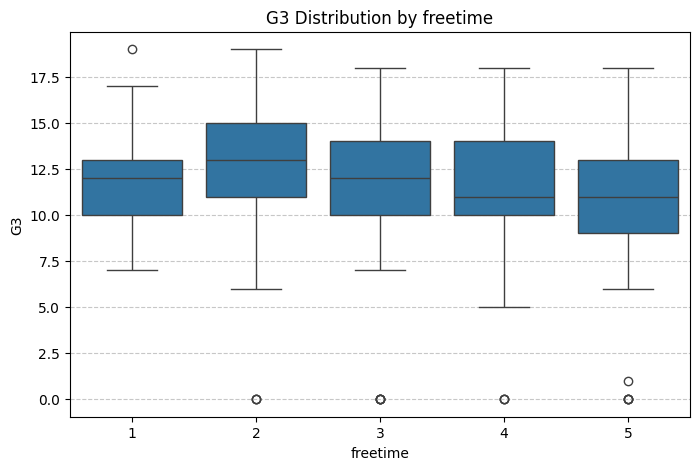


--- Analyzing column: goout ---
F-statistic for goout: 6.985936355765734
p-value for goout: 1.6524803939952414e-05
For goout, we reject the null hypothesis (significant influence on G3).


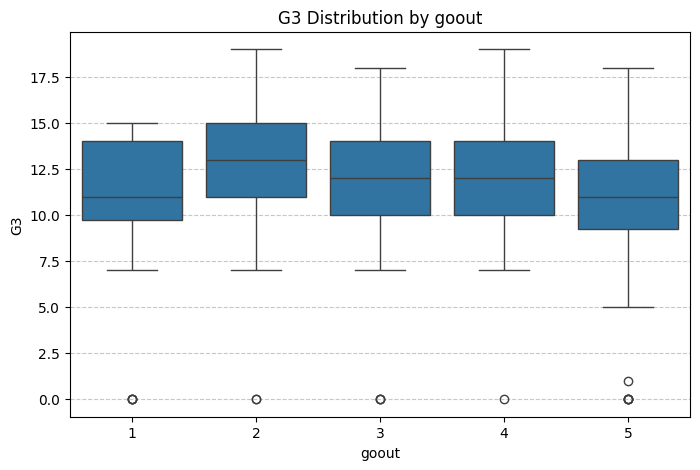


--- Analyzing column: Dalc ---
F-statistic for Dalc: 8.193253061643448
p-value for Dalc: 1.8989671842550212e-06
For Dalc, we reject the null hypothesis (significant influence on G3).


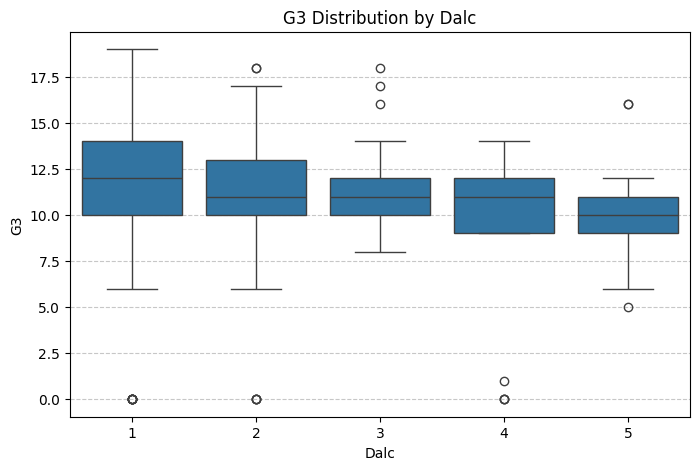


--- Analyzing column: Walc ---
F-statistic for Walc: 5.535392164574902
p-value for Walc: 0.00021933854464991427
For Walc, we reject the null hypothesis (significant influence on G3).


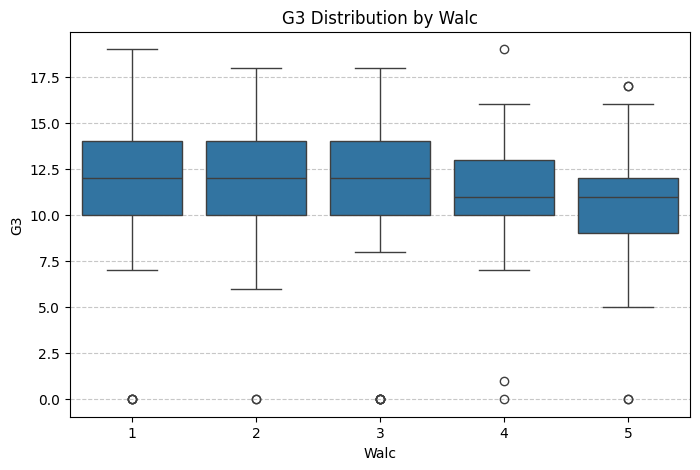


--- Analyzing column: health ---
F-statistic for health: 2.44028666237971
p-value for health: 0.04574054303645168
For health, we reject the null hypothesis (significant influence on G3).


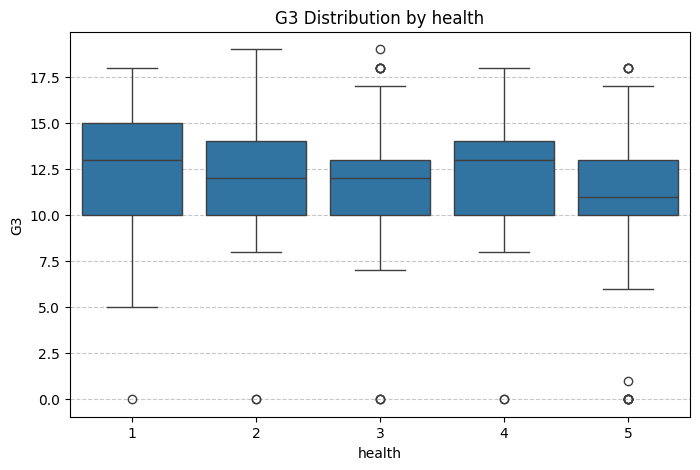


--- Final Summary of ALL Significant Categorical/Ordinal Columns (p-value < 0.05) ---
['school', 'sex', 'address', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'traveltime', 'studytime', 'failures', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health']


In [ ]:
# Identify all columns that could be treated as categorical/ordinal (1 to 5 unique values)
# This includes 'object' dtypes and 'int64' dtypes with a small number of unique values

all_potential_categorical_cols = []

for col in df.columns:
    if df[col].dtype == 'object':
        if 1 <= df[col].nunique() <= 5:
            all_potential_categorical_cols.append(col)
    elif df[col].dtype == 'int64' and col not in ['age', 'absences', 'G1', 'G2', 'G3']: # Exclude purely continuous/target features
        if 1 <= df[col].nunique() <= 5:
            all_potential_categorical_cols.append(col)

print("All potential categorical/ordinal columns with 1 to 5 unique categories:")
print(all_potential_categorical_cols)

significant_all_cols = []

for col in all_potential_categorical_cols:
    print(f"\n--- Analyzing column: {col} ---")

    unique_categories = df[col].unique()
    g3_scores_by_category = [df[df[col] == category]['G3'] for category in unique_categories]

    if len(g3_scores_by_category) > 1:
        # Filter out empty arrays that can cause issues with f_oneway
        g3_scores_by_category_filtered = [arr for arr in g3_scores_by_category if not arr.empty]

        if len(g3_scores_by_category_filtered) > 1:
            f_statistic, p_value = f_oneway(*g3_scores_by_category_filtered)

            print(f"F-statistic for {col}: {f_statistic}")
            print(f"p-value for {col}: {p_value}")

            if p_value < 0.05:
                print(f"For {col}, we reject the null hypothesis (significant influence on G3).")
                significant_all_cols.append(col)
            else:
                print(f"For {col}, we accept the null hypothesis (non-significant influence on G3).")

            # Generate boxplot for visualization
            fig, ax = plt.subplots(figsize=(8, 5))
            sns.boxplot(x=col, y='G3', data=df, ax=ax)
            plt.title(f'G3 Distribution by {col}')
            plt.xlabel(col)
            plt.ylabel('G3')
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.show()
        else:
            print(f"Skipping ANOVA for {col} as there are not enough valid categories with G3 scores.")
    else:
        print(f"Skipping ANOVA for {col} as it has only one category.")

print("\n--- Final Summary of ALL Significant Categorical/Ordinal Columns (p-value < 0.05) ---")
print(significant_all_cols)

### Re-checking ANOVA for all Potential Categorical/Ordinal Columns (1-5 Unique Categories) without Box Plots

In [ ]:
from scipy.stats import f_oneway

# Re-using 'all_potential_categorical_cols' from previous analysis
# If this cell is run independently, 'all_potential_categorical_cols' would need to be re-defined.
# For continuity, assuming it's available in the kernel state.

# Identify all columns that could be treated as categorical/ordinal (1 to 5 unique values)
# This includes 'object' dtypes and 'int64' dtypes with a small number of unique values

# Redefine all_potential_categorical_cols in case this cell is run out of sequence
all_potential_categorical_cols = []

for col in df.columns:
    if df[col].dtype == 'object':
        if 1 <= df[col].nunique() <= 5:
            all_potential_categorical_cols.append(col)
    elif df[col].dtype == 'int64' and col not in ['age', 'absences', 'G1', 'G2', 'G3']: # Exclude purely continuous/target features
        if 1 <= df[col].nunique() <= 5:
            all_potential_categorical_cols.append(col)

significant_all_cols_recheck = []

for col in all_potential_categorical_cols:
    print(f"\n--- Analyzing column: {col} ---")

    unique_categories = df[col].unique()
    g3_scores_by_category = [df[df[col] == category]['G3'] for category in unique_categories]

    if len(g3_scores_by_category) > 1:
        # Filter out empty arrays that can cause issues with f_oneway
        g3_scores_by_category_filtered = [arr for arr in g3_scores_by_category if not arr.empty]

        if len(g3_scores_by_category_filtered) > 1:
            f_statistic, p_value = f_oneway(*g3_scores_by_category_filtered)

            print(f"F-statistic for {col}: {f_statistic}")
            print(f"p-value for {col}: {p_value}")

            if p_value < 0.05:
                print(f"For {col}, we reject the null hypothesis (significant influence on G3).")
                significant_all_cols_recheck.append(col)
            else:
                print(f"For {col}, we accept the null hypothesis (non-significant influence on G3).")
        else:
            print(f"Skipping ANOVA for {col} as there are not enough valid categories with G3 scores.")
    else:
        print(f"Skipping ANOVA for {col} as it has only one category.")

print("\n--- Final Summary of ALL Significant Categorical/Ordinal Columns (p-value < 0.05) ---")
print(significant_all_cols_recheck)



--- Analyzing column: school ---
F-statistic for school: 56.890676863371326
p-value for school: 1.5661990923002604e-13
For school, we reject the null hypothesis (significant influence on G3).

--- Analyzing column: sex ---
F-statistic for sex: 10.962308407124876
p-value for sex: 0.0009815287061373291
For sex, we reject the null hypothesis (significant influence on G3).

--- Analyzing column: address ---
F-statistic for address: 18.707910527412754
p-value for address: 1.7641534609222376e-05
For address, we reject the null hypothesis (significant influence on G3).

--- Analyzing column: famsize ---
F-statistic for famsize: 1.3137906447644496
p-value for famsize: 0.2521332216658235
For famsize, we accept the null hypothesis (non-significant influence on G3).

--- Analyzing column: Pstatus ---
F-statistic for Pstatus: 0.0003677569375753126
p-value for Pstatus: 0.984705825951084
For Pstatus, we accept the null hypothesis (non-significant influence on G3).

--- Analyzing column: Medu ---
F-

### Selecting Top 10 Most Significant Categorical/Ordinal Columns

In [ ]:
from scipy.stats import f_oneway

# Re-identifying all potential categorical/ordinal columns as done previously
all_potential_categorical_cols = []

for col in df.columns:
    if df[col].dtype == 'object':
        if 1 <= df[col].nunique() <= 5:
            all_potential_categorical_cols.append(col)
    elif df[col].dtype == 'int64' and col not in ['age', 'absences', 'G1', 'G2', 'G3']:
        if 1 <= df[col].nunique() <= 5:
            all_potential_categorical_cols.append(col)

# Dictionary to store p-values for significant columns
p_values_map = {}

print("--- Re-evaluating p-values for all potential categorical/ordinal columns ---")
for col in all_potential_categorical_cols:
    unique_categories = df[col].unique()
    g3_scores_by_category = [df[df[col] == category]['G3'] for category in unique_categories]

    if len(g3_scores_by_category) > 1:
        g3_scores_by_category_filtered = [arr for arr in g3_scores_by_category if not arr.empty]

        if len(g3_scores_by_category_filtered) > 1:
            f_statistic, p_value = f_oneway(*g3_scores_by_category_filtered)
            p_values_map[col] = p_value
            print(f"Column: {col}, p-value: {p_value}")

# Filter for statistically significant columns (p-value < 0.05)
significant_cols_with_pvalues = {col: p_value for col, p_value in p_values_map.items() if p_value < 0.05}

# Sort the significant columns by their p-value in ascending order
sorted_significant_cols = sorted(significant_cols_with_pvalues.items(), key=lambda item: item[1])

# Select the top 10 most significant columns
top_10_significant_cols = [col for col, p_value in sorted_significant_cols[:10]]

print("\n--- Top 10 Most Significant Categorical/Ordinal Columns (sorted by p-value) ---")
print(top_10_significant_cols)

--- Re-evaluating p-values for all potential categorical/ordinal columns ---
Column: school, p-value: 1.5661990923002604e-13
Column: sex, p-value: 0.0009815287061373291
Column: address, p-value: 1.7641534609222376e-05
Column: famsize, p-value: 0.2521332216658235
Column: Pstatus, p-value: 0.984705825951084
Column: Medu, p-value: 1.8856851949016492e-08
Column: Fedu, p-value: 1.7991136867942303e-06
Column: Mjob, p-value: 8.305149884947421e-06
Column: Fjob, p-value: 0.01137628062360572
Column: reason, p-value: 1.3416422874904325e-06
Column: guardian, p-value: 0.07226239503367193
Column: traveltime, p-value: 0.012321097062069852
Column: studytime, p-value: 5.705728458962843e-10
Column: failures, p-value: 8.644516356430469e-30
Column: schoolsup, p-value: 0.09097103846579589
Column: famsup, p-value: 0.13188651204202523
Column: paid, p-value: 0.1624412486356955
Column: activities, p-value: 0.12809905950542522
Column: nursery, p-value: 0.46464524309828237
Column: higher, p-value: 3.499659592829

### Function to Filter Non-Categorical Columns

In [ ]:
def filter_non_categorical_columns(df, categorical_cols_to_keep):
    """
    Filters a DataFrame to include only the specified categorical columns.

    Args:
        df (pd.DataFrame): The input DataFrame.
        categorical_cols_to_keep (list): A list of column names to keep.

    Returns:
        pd.DataFrame: A new DataFrame containing only the specified categorical columns.
    """
    # Ensure that all columns to keep actually exist in the DataFrame
    existing_categorical_cols = [col for col in categorical_cols_to_keep if col in df.columns]
    if len(existing_categorical_cols) != len(categorical_cols_to_keep):
        print("Warning: Some specified categorical columns were not found in the DataFrame.")

    return df[existing_categorical_cols]

# Demonstrate the function using the top 10 significant columns
df_filtered_top_10_categorical = filter_non_categorical_columns(df, top_10_significant_cols)

print("\n--- Filtered DataFrame with Top 10 Significant Categorical Columns ---")
display(df_filtered_top_10_categorical.head())
print(f"Shape of the filtered DataFrame: {df_filtered_top_10_categorical.shape}")


--- Filtered DataFrame with Top 10 Significant Categorical Columns ---


,failures,higher,school,studytime,Medu,reason,Fedu,Dalc,Mjob,goout
0,0,yes,GP,2,4,course,4,1,at_home,4
1,0,yes,GP,2,1,course,1,1,at_home,3
2,0,yes,GP,2,1,other,1,2,at_home,2
3,0,yes,GP,3,4,home,2,1,health,2
4,0,yes,GP,2,3,home,3,1,other,2


Shape of the filtered DataFrame: (649, 10)


### Creating a New DataFrame with Selected Features

In [ ]:
# Columns from the top 10 significant categorical/ordinal features
selected_features = top_10_significant_cols.copy()

# Add continuous numerical columns and target variables that were not part of the 1-5 categories check
# These were explicitly excluded in previous steps and are typically important for modeling.
continuous_numerical_cols = ['age', 'absences', 'G1', 'G2', 'G3']
selected_features.extend(continuous_numerical_cols)

# Create the new DataFrame
df_new= df[selected_features]

print("--- New DataFrame with Top 10 Significant Categorical/Ordinal Features and Key Numerical Features ---")
display(df_new.head())
print(f"Shape of the final features DataFrame: {df_new.shape}")

--- New DataFrame with Top 10 Significant Categorical/Ordinal Features and Key Numerical Features ---


,failures,higher,school,studytime,Medu,reason,Fedu,Dalc,Mjob,goout,age,absences,G1,G2,G3
0,0,yes,GP,2,4,course,4,1,at_home,4,18,4,0,11,11
1,0,yes,GP,2,1,course,1,1,at_home,3,17,2,9,11,11
2,0,yes,GP,2,1,other,1,2,at_home,2,15,6,12,13,12
3,0,yes,GP,3,4,home,2,1,health,2,15,0,14,14,14
4,0,yes,GP,2,3,home,3,1,other,2,16,0,11,13,13


Shape of the final features DataFrame: (649, 15)


In [ ]:
df_new.head()

,failures,higher,school,studytime,Medu,reason,Fedu,Dalc,Mjob,goout,age,absences,G1,G2,G3
0,0,yes,GP,2,4,course,4,1,at_home,4,18,4,0,11,11
1,0,yes,GP,2,1,course,1,1,at_home,3,17,2,9,11,11
2,0,yes,GP,2,1,other,1,2,at_home,2,15,6,12,13,12
3,0,yes,GP,3,4,home,2,1,health,2,15,0,14,14,14
4,0,yes,GP,2,3,home,3,1,other,2,16,0,11,13,13


In [ ]:
# Identify categorical (object) columns to be encoded
cat_features_to_encode = df_new.select_dtypes(include=['object']).columns.tolist()

# Apply one-hot encoding using get_dummies
df_encoded = pd.get_dummies(df_new, columns=cat_features_to_encode, drop_first=True)

# Convert boolean results to integers (0/1)
df_encoded = df_encoded.astype(int)

print(f"Encoded features: {cat_features_to_encode}")
display(df_encoded.head())

Encoded features: ['higher', 'school', 'reason', 'Mjob']


,failures,studytime,Medu,Fedu,Dalc,goout,age,absences,G1,G2,G3,higher_yes,school_MS,reason_home,reason_other,reason_reputation,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher
0,0,2,4,4,1,4,18,4,0,11,11,1,0,0,0,0,0,0,0,0
1,0,2,1,1,1,3,17,2,9,11,11,1,0,0,0,0,0,0,0,0
2,0,2,1,1,2,2,15,6,12,13,12,1,0,0,1,0,0,0,0,0
3,0,3,4,2,1,2,15,0,14,14,14,1,0,1,0,0,1,0,0,0
4,0,2,3,3,1,2,16,0,11,13,13,1,0,1,0,0,0,1,0,0


In [ ]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns that need scaling
# We exclude the columns that were just created by one-hot encoding
# These are: failures, studytime, Medu, Fedu, Dalc, goout, age, absences, G1, G2, G3
scaling_cols = ['failures', 'studytime', 'Medu', 'Fedu', 'Dalc', 'goout', 'age', 'absences', 'G1', 'G2', 'G3']

scaler = StandardScaler()

# Apply StandardScaler
df_encoded[scaling_cols] = scaler.fit_transform(df_encoded[scaling_cols])

print("--- Standardized Encoded DataFrame ---")
display(df_encoded.head())

--- Standardized Encoded DataFrame ---


,failures,studytime,Medu,Fedu,Dalc,goout,age,absences,G1,G2,G3,higher_yes,school_MS,reason_home,reason_other,reason_reputation,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher
0,-0.374305,0.083653,1.310216,1.540715,-0.543555,0.693785,1.031695,0.073433,-4.155470,-0.195820,-0.280658,1,0,0,0,0,0,0,0,0
1,-0.374305,0.083653,-1.336039,-1.188832,-0.543555,-0.157380,0.210137,-0.357863,-0.874570,-0.195820,-0.280658,1,0,0,0,0,0,0,0,0
2,-0.374305,0.083653,-1.336039,-1.188832,0.538553,-1.008546,-1.432980,0.504730,0.219064,0.491137,0.029116,1,0,0,1,0,0,0,0,0
3,-0.374305,1.290114,1.310216,-0.278983,-0.543555,-1.008546,-1.432980,-0.789159,0.948153,0.834615,0.648663,1,0,1,0,0,1,0,0,0
4,-0.374305,0.083653,0.428131,0.630866,-0.543555,-1.008546,-0.611422,-0.789159,-0.145481,0.491137,0.338889,1,0,1,0,0,0,1,0,0
